<a href="https://colab.research.google.com/github/Srihitha-M/NASSCOM/blob/main/U6_Probability_Statistics_Part1_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns

df = sns.load_dataset("tips")

# 1. Numerical vs categorical columns
numerical = df.select_dtypes(include="number").columns.tolist()
categorical = df.select_dtypes(exclude="number").columns.tolist()
print("Numerical columns  :", numerical)
print("Categorical columns:", categorical)

# 2. Mean of a numerical column (tip)
print("\nMean tip:", round(df["tip"].mean(), 2))

# 3. Value counts of a categorical column (sex)
print("\nSex value counts:")
print(df["sex"].value_counts())

Numerical columns  : ['total_bill', 'tip', 'size']
Categorical columns: ['sex', 'smoker', 'day', 'time']

Mean tip: 3.0

Sex value counts:
sex
Male      157
Female     87
Name: count, dtype: int64


Mean   : 3.0
Median : 2.9
Mode   : 2.0
Is right-skewed (mean > median)? True


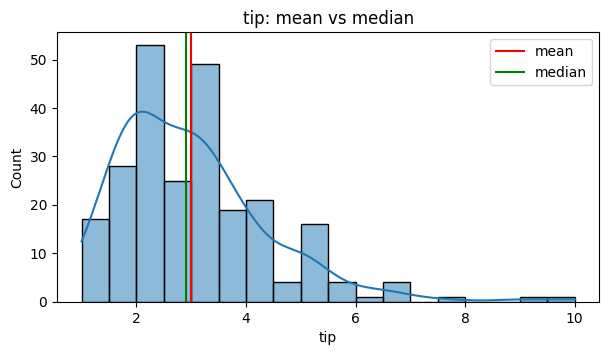

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("tips")
tip = df["tip"]

# 1. mean, median, mode
mean_val = tip.mean()
median_val = tip.median()
mode_val = tip.mode()[0]

print("Mean   :", round(mean_val, 2))
print("Median :", round(median_val, 2))
print("Mode   :", round(mode_val, 2))

# 2. mean > median ?
print("Is right-skewed (mean > median)?", mean_val > median_val)

# 3. histogram with mean & median lines
plt.figure(figsize=(7, 3.5))
sns.histplot(tip, kde=True)
plt.axvline(mean_val, color="red", label="mean")
plt.axvline(median_val, color="green", label="median")
plt.legend()
plt.title("tip: mean vs median")
plt.show()

In [3]:
import seaborn as sns

df = sns.load_dataset("tips")
tip = df["tip"]

# 1. range, variance, std
tip_range = tip.max() - tip.min()
tip_var = tip.var()
tip_std = tip.std()

print("Range   :", round(tip_range, 2))
print("Variance:", round(tip_var, 2))
print("Std Dev :", round(tip_std, 2))

# 2. Q1, Q3, IQR
q1 = tip.quantile(0.25)
q3 = tip.quantile(0.75)
iqr = q3 - q1

print("Q1 (25%):", round(q1, 2))
print("Q3 (75%):", round(q3, 2))
print("IQR     :", round(iqr, 2))

# 3. Most robust measure of spread:
# The Interquartile Range (IQR) is the most robust measure of spread because it
# focuses exclusively on the middle 50% of the distribution, making it immune to
# extreme values and outliers.

Range   : 9.0
Variance: 1.91
Std Dev : 1.38
Q1 (25%): 2.0
Q3 (75%): 3.56
IQR     : 1.56


Five-number summary:
min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64

Skewness: 1.465


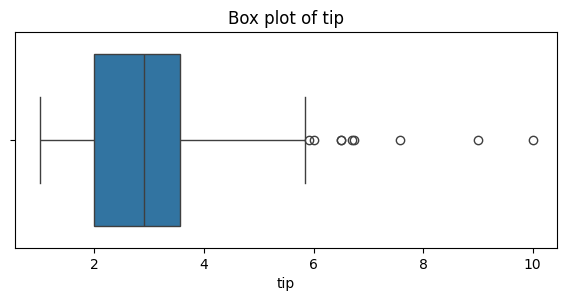

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("tips")
tip = df["tip"]

# 1. five-number summary
five_num = tip.describe()[["min", "25%", "50%", "75%", "max"]]
print("Five-number summary:")
print(five_num)

# 2. skewness (+ comment on the direction of the lean)
skew_val = tip.skew()
print("\nSkewness:", round(skew_val, 3))
# Skewness > 0 (~1.085) indicates that the distribution leans to the right (right-skewed),
# with a longer tail of higher tip amounts.

# 3. box plot of tip
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=tip)
plt.title("Box plot of tip")
plt.show()

Correlation Matrix:
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


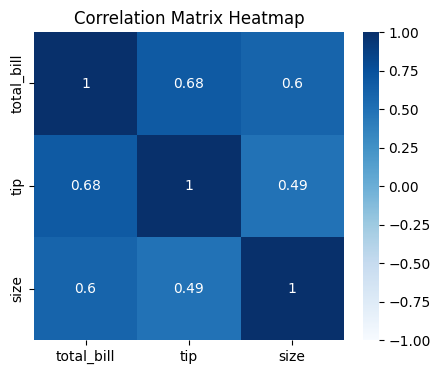


Dataset Summary:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("tips")

# 1. correlation matrix (rounded)
corr = df.corr(numeric_only=True)
print("Correlation Matrix:")
print(corr.round(2))

# 2. heatmap of the correlation matrix
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.show()

# 3. df.describe() + 3 insights as comments
summary = df.describe()
print("\nDataset Summary:")
print(summary)

# Insight 1: 'total_bill' has the highest standard deviation (~8.90), showing the largest overall spread in numerical values.
# Insight 2: 'total_bill' and 'tip' have a strong positive correlation (~0.68), indicating larger bills lead to higher tips.
# Insight 3: The mean total bill ($19.79) is noticeably higher than the median ($17.80), indicating right-skewness across bills.